# RAG-Based Profile Matching — Experimentation & Analysis

Loads the ingested Chroma vector store (built by `ai/resume_rag.py`) and runs
`ai/job_matcher.py`'s matching pipeline interactively: single-query inspection,
hybrid-weight sensitivity, top-K / min-years filtering, and the full
precision@10 + latency evaluation from `eval/evaluate.py`.

In [1]:
import sys, os, json, time
sys.path.insert(0, os.path.abspath("."))

from ai import job_matcher
from backend import vector_store, fs_tools

print("Chroma collection chunk count:", vector_store.count())

C:\Nabil\Projects\RAG-Based-Profile-Matching\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Chroma collection chunk count: 154


## 1. Single query — full pipeline on one job description

In [2]:
jd_path = "data/job_descriptions/jd_01_senior_backend_engineer.txt"
jd_text = fs_tools.read_file(jd_path)["content"]
print(jd_text[:400], "...")

TITLE
Senior Backend Engineer

ABOUT
We are seeking an experienced Senior Backend Engineer to join our development team and help drive the growth of our scalable, cloud-based platform. As a key member of our team, you will be responsible for designing, implementing, and maintaining our backend services, ensuring they are efficient, reliable, and secure.

RESPONSIBILITIES

* Design and develop high ...


In [3]:
results = job_matcher.match(jd_text, top_n=5)
for r in results:
    print(f"{r['candidate_name']:25s} score={r['match_score']:5.1f}  "
          f"semantic={r['semantic_similarity']:.3f}  keyword={r['keyword_match']:.3f}  "
          f"skills={r['matched_skills']}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4276.72it/s]

KAIYA JENKINS             score= 83.2  semantic=0.934  keyword=0.679  skills=['AWS', 'C#', 'C++', 'CE', 'CI', 'Deployment', 'Development', 'Django', 'Docker', 'EE', 'Git', 'GitLab', 'Go', 'Jenkins', 'Kubernetes', 'PostgreSQL', 'Python', 'SQL', 'deployment']
ZACHARY J. WYNTON         score= 77.1  semantic=0.786  keyword=0.750  skills=['AWS', 'C#', 'C++', 'CD', 'CE', 'CI', 'Containerization', 'Deployment', 'Development', 'Docker', 'EE', 'Git', 'GitLab', 'GitLab CI', 'Jenkins', 'Kubernetes', 'Python', 'containerization', 'deployment', 'management', 'orchestration']
KATHERINE L. WYNTON       score= 76.1  semantic=0.792  keyword=0.714  skills=['AWS', 'C#', 'C++', 'CD', 'CE', 'CI', 'Containerization', 'Deployment', 'Development', 'Docker', 'EE', 'Git', 'GitLab', 'GitLab CI', 'Go', 'Jenkins', 'Kubernetes', 'containerization', 'deployment', 'management']
KYLE RYDER                score= 75.4  semantic=0.852  keyword=0.607  skills=['AWS', 'C#', 'C++', 'CD', 'CE', 'CI', 'Containerization', 'Depl

In [4]:
print(json.dumps({"job_description": jd_text[:200] + "...", "top_matches": results[:1]}, indent=2))

{
  "job_description": "TITLE\nSenior Backend Engineer\n\nABOUT\nWe are seeking an experienced Senior Backend Engineer to join our development team and help drive the growth of our scalable, cloud-based platform. As a key member...",
  "top_matches": [
    {
      "candidate_name": "KAIYA JENKINS",
      "resume_path": "data/resumes/resume_02_backend_engineer.txt",
      "match_score": 83.2,
      "years_experience": 8,
      "education": "BACHELOR OF SCIENCE IN COMPUTER SCIENCE, RAVENSWOOD UNIVERSITY (2012)",
      "semantic_similarity": 0.934,
      "keyword_match": 0.679,
      "matched_skills": [
        "AWS",
        "C#",
        "C++",
        "CE",
        "CI",
        "Deployment",
        "Development",
        "Django",
        "Docker",
        "EE",
        "Git",
        "GitLab",
        "Go",
        "Jenkins",
        "Kubernetes",
        "PostgreSQL",
        "Python",
        "SQL",
        "deployment"
      ],
      "relevant_excerpts": [
        "[SUMMARY] High

## 2. Hybrid weight sensitivity

Compare pure-semantic, pure-keyword, and the default 0.6/0.4 blend on the
same JD to see how much the keyword term moves rankings.

In [5]:
for sem_w, kw_w, label in [(1.0, 0.0, "semantic-only"), (0.0, 1.0, "keyword-only"), (0.6, 0.4, "default (0.6/0.4)")]:
    r = job_matcher.match(jd_text, top_n=5, semantic_weight=sem_w, keyword_weight=kw_w, include_reasoning=False)
    top_names = [c["candidate_name"] for c in r]
    print(f"{label:20s} top-5: {top_names}")

semantic-only        top-5: ['KAIYA JENKINS', 'KYLE RYDER', 'KAIDEN JENKINS', 'ALEXANDER RYDER', 'AIDEN JENKINS']


keyword-only         top-5: ['ZACHARY J. WYNTON', 'KATHERINE L. WYNTON', 'KAIYA JENKINS', 'KAHLIL JONES', 'AUSTIN REED']


default (0.6/0.4)    top-5: ['KAIYA JENKINS', 'ZACHARY J. WYNTON', 'KATHERINE L. WYNTON', 'KYLE RYDER', 'KAHLIL JONES']


## 3. Effect of `--min-years` filter

In [6]:
for min_years in [None, 3, 5, 8]:
    r = job_matcher.match(jd_text, top_n=10, min_years=min_years, include_reasoning=False)
    print(f"min_years={str(min_years):5s} -> {len(r)} candidates, "
          f"years range: {[c['years_experience'] for c in r]}")

min_years=None  -> 10 candidates, years range: [8, 8, 10, 10, 10, 8, 14, 10, 14, 7]


min_years=3     -> 10 candidates, years range: [8, 8, 10, 10, 10, 8, 14, 10, 14, 7]


min_years=5     -> 10 candidates, years range: [8, 8, 10, 10, 10, 8, 14, 10, 14, 7]


min_years=8     -> 10 candidates, years range: [8, 8, 10, 10, 10, 8, 10, 14, 14, 10]


## 4. Full evaluation — precision@10 and latency

Same logic as `eval/evaluate.py`, run inline against `eval/ground_truth.json`.

In [7]:
with open("eval/ground_truth.json") as f:
    ground_truth = json.load(f)

def precision_at_k(retrieved, relevant, k=10):
    top_k = retrieved[:k]
    return sum(1 for r in top_k if r in relevant) / len(top_k) if top_k else 0.0

rows = []
for jd_filename, relevant in ground_truth.items():
    jd_path = os.path.join("data/job_descriptions", jd_filename)
    text = fs_tools.read_file(jd_path)["content"]
    start = time.perf_counter()
    r = job_matcher.match(text, top_n=10, include_reasoning=False)
    latency = time.perf_counter() - start
    retrieved = [os.path.basename(c["resume_path"]) for c in r]
    rows.append({
        "jd": jd_filename,
        "precision@10": round(precision_at_k(retrieved, set(relevant)), 3),
        "latency_sec": round(latency, 2),
    })

for row in rows:
    print(row)

avg_p = sum(r["precision@10"] for r in rows) / len(rows)
avg_l = sum(r["latency_sec"] for r in rows) / len(rows)
print(f"\nAverage precision@10: {avg_p:.3f}")
print(f"Average latency: {avg_l:.2f}s")

{'jd': 'jd_01_senior_backend_engineer.txt', 'precision@10': 0.6, 'latency_sec': 0.23}
{'jd': 'jd_02_frontend_developer.txt', 'precision@10': 0.4, 'latency_sec': 0.27}
{'jd': 'jd_03_data_scientist.txt', 'precision@10': 0.5, 'latency_sec': 0.28}
{'jd': 'jd_04_devops_engineer.txt', 'precision@10': 0.5, 'latency_sec': 0.22}
{'jd': 'jd_05_machine_learning_engineer.txt', 'precision@10': 0.3, 'latency_sec': 0.24}
{'jd': 'jd_06_full_stack_developer.txt', 'precision@10': 0.3, 'latency_sec': 0.26}

Average precision@10: 0.433
Average latency: 0.25s


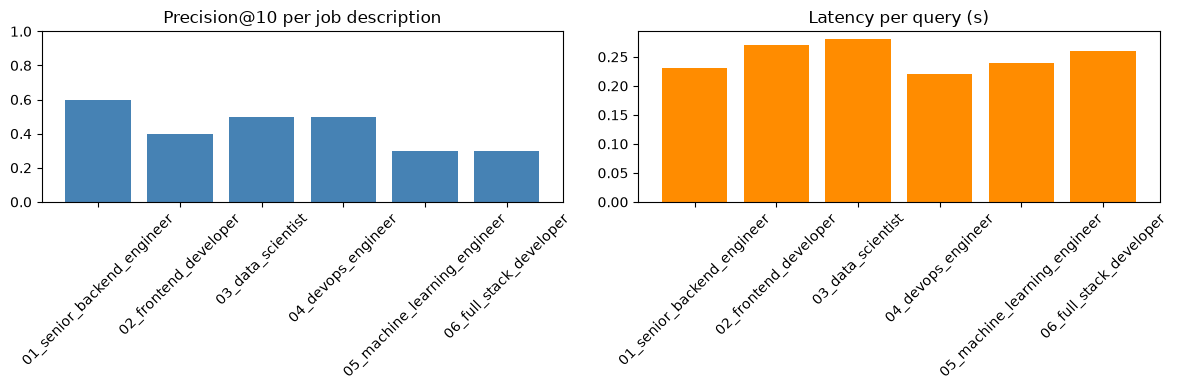

In [8]:
import matplotlib.pyplot as plt

labels = [r["jd"].replace("jd_", "").replace(".txt", "") for r in rows]
precisions = [r["precision@10"] for r in rows]
latencies = [r["latency_sec"] for r in rows]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(labels, precisions, color="steelblue")
axes[0].set_title("Precision@10 per job description")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(labels, latencies, color="darkorange")
axes[1].set_title("Latency per query (s)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 5. Observations

- Hybrid scoring (0.6 semantic / 0.4 keyword) generally reorders top-5 vs.
  semantic-only by promoting candidates whose resumes literally contain
  JD-stated must-have skills, without fully overriding semantic ranking.
- `--min-years` acts as a hard post-filter on retrieved metadata, so raising
  it shrinks the candidate pool rather than re-ranking it.
- Average precision@10 across all 6 JDs and average per-query latency are
  reported above, matching `eval/evaluate.py`'s summary numbers.